In [180]:
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.datasource import YahooDataSource
from src.prediction import PredictionModeling
from src.bayesianopt import bayesianOpt
from src.gridsearchopt import gridsearchOpt
from src.riskmeasure import CumulativeReturn, ExponationalUtility, MeanSemiDeviation
from src.utils import buy_signal_plots, calculate_drawdown
from src.utils import find_cointegrated_pairs,get_top_k_pairs,get_cointergrated_coeff
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Data Extraction

In [181]:
# Extract the Data from the Yahoo Data Source
start_date = datetime.datetime(2019, 3, 29)
end_date = datetime.datetime(2024, 3, 29)
tickers  =  ['SPY','AAPL','ADBE','EBAY','MSFT','QCOM',
                 'HPQ','JNPR','AMD','IBM','DAL','KO']
columns =   ["High","Close","Low","Volume"]
ds = YahooDataSource(start_date,end_date,tickers,columns)

In [182]:
# Get only Close column data
df_pair_search = ds.get_data_by_column_tickers(columns=["Close"],tickers=-1)

In [183]:
df_pair_search.head(n=5)
scores, pvalues, pairs = find_cointegrated_pairs(df_pair_search)

top_pairs = get_top_k_pairs(pairs,5)
print("Top pairs",top_pairs)

# Get first pair
tickers = ds.get_tickers(top_pairs[0][0])
print("Top ticker",tickers)

Top pairs [(('AMD_Close', 'MSFT_Close'), 0.01801044508073984)]
Top ticker ['AMD', 'MSFT']


In [184]:
first_series = 'MSFT_Close'
second_series =  'AMD_Close'

In [185]:
# Gather High, Low ,Close , Volume of selected stocks
columns = ["High","Close","Low","Volume"]
df_raw = ds.get_data_by_column_tickers(columns=columns,tickers=tickers)

In [186]:
df_raw

,MSFT_Low,MSFT_Close,MSFT_Volume,MSFT_High,AMD_Low,AMD_Close,AMD_Volume,AMD_High
0,110.287302,111.211395,25399800,111.569713,25.250000,25.520000,53502800,25.730000
1,111.362286,112.229797,22789100,112.314667,25.830000,26.360001,63000300,26.559999
2,111.758310,112.390091,18142300,112.663547,26.090000,26.750000,53358800,26.799999
3,112.352354,113.125572,22860700,113.559328,27.879999,29.020000,197650500,29.950001
4,111.626299,112.550392,20112800,113.370760,28.610001,29.090000,82191100,29.389999
...,...,...,...,...,...,...,...,...
1254,422.066925,424.711823,17648500,425.821295,175.050003,179.649994,57899100,180.759995
1255,417.648799,418.887054,18060500,423.394324,172.000000,178.630005,71935300,182.800003
1256,417.391216,417.688385,16725600,421.987605,176.330002,177.869995,65322400,182.600006
1257,415.073243,417.470490,16705000,420.462135,175.399994,179.589996,55685600,181.229996


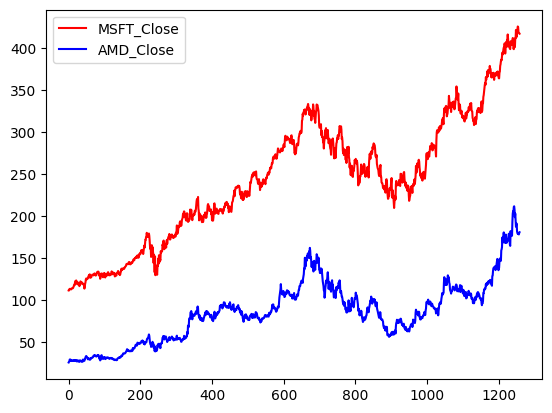

In [187]:
plt.plot(df_raw[first_series],color='r')
plt.plot(df_raw[second_series],color='b')
plt.legend([f'{first_series}',f'{second_series}'])

In [188]:
# Find ratio between co-integrated pairs
coeff = get_cointergrated_coeff(df_raw[first_series],df_raw[second_series])
print(coeff)

-1.936183193942497


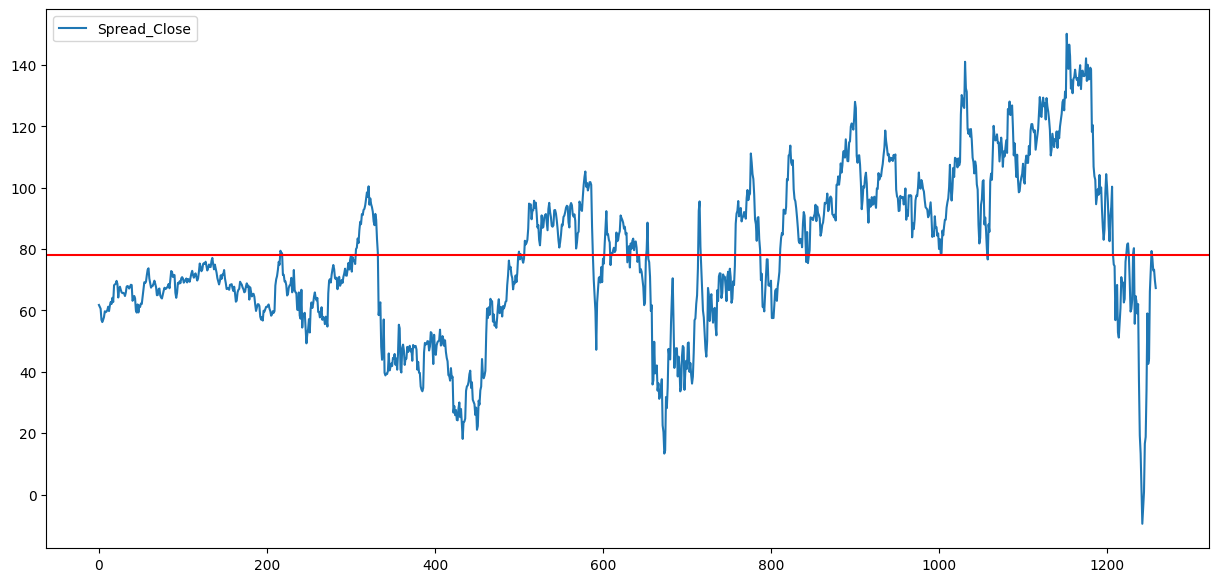

In [189]:
df_raw['Spread_Close'] = df_raw[first_series] + (df_raw[second_series] * coeff)
df_raw['Spread_Close'].plot(figsize=(15,7))
plt.axhline(df_raw['Spread_Close'].mean(),c='red')
plt.legend(['Spread_Close'])

In [190]:
pm = PredictionModeling(df_raw,"Spread_Close",0.60,1)

In [191]:
pm.add_arima_forecast("Spread_Close",order=(1,1,0))

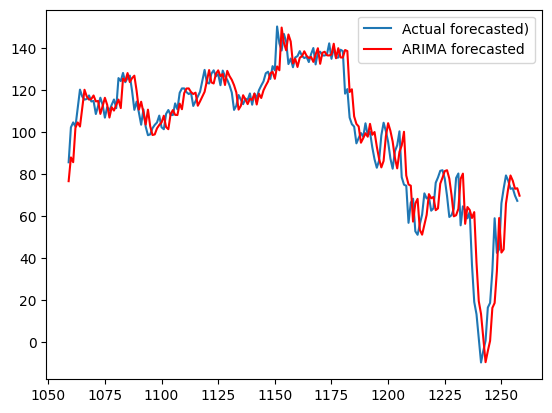

In [192]:
plt.plot(pm.data["Spread_Close_Actual_value_fore_perod_1"][-200:])
plt.plot(pm.data["Spread_Close_ARIMA_forecast_1"][-200:],color='r')
plt.legend(["Actual forecasted)","ARIMA forecasted"])

In [193]:
pm.data

,MSFT_Low,MSFT_Close,MSFT_Volume,MSFT_High,AMD_Low,AMD_Close,AMD_Volume,AMD_High,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,110.287302,111.211395,25399800,111.569713,25.250000,25.520000,53502800,25.730000,61.799999,[61.192007189204595],61.192007,61.192007,NaN,NaN
1,111.362286,112.229797,22789100,112.314667,25.830000,26.360001,63000300,26.559999,61.192007,[60.59719050442102],60.597191,60.597191,NaN,NaN
2,111.758310,112.390091,18142300,112.663547,26.090000,26.750000,53358800,26.799999,60.597191,[56.937535030064254],56.937535,56.937535,NaN,NaN
3,112.352354,113.125572,22860700,113.559328,27.879999,29.020000,197650500,29.950001,56.937535,[56.226822743653564],56.226823,56.226823,NaN,NaN
4,111.626299,112.550392,20112800,113.370760,28.610001,29.090000,82191100,29.389999,56.226823,[56.93955993611468],56.939560,56.939560,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,422.066925,424.711823,17648500,425.821295,175.050003,179.649994,57899100,180.759995,76.876524,[73.02664105539162],73.026641,73.026641,79.360708,[79.36070837103576]
1255,417.648799,418.887054,18060500,423.394324,172.000000,178.630005,71935300,182.800003,73.026641,[73.29948975723318],73.299490,73.299490,76.885092,[76.88509207349239]
1256,417.391216,417.688385,16725600,421.987605,176.330002,177.869995,65322400,182.600006,73.299490,[69.75135679233472],69.751357,69.751357,73.038630,[73.03862957772103]
1257,415.073243,417.470490,16705000,420.462135,175.399994,179.589996,55685600,181.229996,69.751357,[67.30543556845305],67.305436,67.305436,73.298631,[73.29863130345828]


In [195]:
pm.data[:907]

,MSFT_Low,MSFT_Close,MSFT_Volume,MSFT_High,AMD_Low,AMD_Close,AMD_Volume,AMD_High,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,110.287302,111.211395,25399800,111.569713,25.250000,25.520000,53502800,25.730000,61.799999,[61.192007189204595],61.192007,61.192007,NaN,NaN
1,111.362286,112.229797,22789100,112.314667,25.830000,26.360001,63000300,26.559999,61.192007,[60.59719050442102],60.597191,60.597191,NaN,NaN
2,111.758310,112.390091,18142300,112.663547,26.090000,26.750000,53358800,26.799999,60.597191,[56.937535030064254],56.937535,56.937535,NaN,NaN
3,112.352354,113.125572,22860700,113.559328,27.879999,29.020000,197650500,29.950001,56.937535,[56.226822743653564],56.226823,56.226823,NaN,NaN
4,111.626299,112.550392,20112800,113.370760,28.610001,29.090000,82191100,29.389999,56.226823,[56.93955993611468],56.939560,56.939560,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,224.844908,226.076355,82543200,232.898125,59.150002,59.730000,79761600,61.770000,110.428134,[108.1495615881789],108.149562,108.149562,125.983873,[125.98387254599984]
903,220.661881,221.609894,40424600,228.392576,58.509998,58.599998,83871400,62.720001,108.149562,[110.46047675281997],110.460477,110.460477,110.576504,[110.57650362420982]
904,220.925805,230.523193,40647700,231.236656,58.919998,62.009998,78198600,62.349998,110.460477,[110.58083092869096],110.580831,110.580831,108.166407,[108.1664069732969]
905,225.910200,226.867996,28357300,229.594745,59.529999,60.060001,73274100,61.860001,110.580831,[107.48503738525842],107.485037,107.485037,110.442701,[110.44270060729343]


# Data Prepareation of Hyperparameter Tuning for Trading Strategy

In [196]:
total_length =(len(pm.data) - pm.train_end_index)-1
train_size = 0.70
length_param_training = int((len(pm.data) - pm.train_end_index)*0.70)

In [197]:
test_data = pm.data[[first_series,second_series,"Spread_Close","Spread_Close_Actual_value_fore_perod_1","Spread_Close_ARIMA_forecast_1"]][pm.train_end_index:-1]

In [198]:

spread_ARIMA_val = test_data["Spread_Close_ARIMA_forecast_1"][:length_param_training]
S1_val = test_data[first_series][:length_param_training]
S2_val = test_data[second_series][:length_param_training]

spread_ARIMA_test = test_data["Spread_Close_ARIMA_forecast_1"][length_param_training:]

S1_test = test_data[first_series][length_param_training:]
S2_test = test_data[second_series][length_param_training:]

In [ ]:
45*4000*6

# Define set of Hyper parameters

In [216]:
sell_treshold_params = np.linspace(0.4,3,5)
buy_threshold_params = np.linspace(-0.4,-3,5)
clear_threshold_params = np.linspace(0,0.3,5)
window1_param = np.arange(30,100,10)
window2_param = np.arange(1,14,3)
window_param = list(zip(window1_param,window2_param))

param_grid = { 'window1':window1_param,
              'window2':window2_param,
              "sell_threshold":sell_treshold_params,
              "buy_threshold":buy_threshold_params,
              "clear_threshold":clear_threshold_params }
config_dict = {"num_iteration":800}

In [200]:
buy_threshold_params


array([-0.35      , -0.87142857, -1.39285714, -1.91428571, -2.43571429,
       -2.95714286, -3.47857143, -4.        ])

# Trading Strategy using Trading Strategy using ARIMA

In [217]:
import itertools
import numpy as np
from sklearn.model_selection import ParameterGrid
from src.utils import trade

class gridsearchOpt:

    def __init__(self, risk_measure):
        self.optimize_results = None
        self.risk_measure = risk_measure

    def optimize(self, beta, spread, S1, S2, param_grid):
        """
        Grid Search Optimization over parameter grid
        """
        best_score = -np.inf
        best_params = None
        all_results = []

        # Print the total length of parameters
        print("Total Parameters :", len(list(ParameterGrid(param_grid))))

        for i, params in enumerate(ParameterGrid(param_grid)):
            window1 = params["window1"]
            window2 = params["window2"]
            sell_threshold = params["sell_threshold"]
            buy_threshold = params["buy_threshold"]
            clear_threshold = params["clear_threshold"]

            money = trade(
                S1, S2, spread, beta, 
                window1, window2,
                sell_threshold, buy_threshold, clear_threshold
            )

            score = self.risk_measure.calculate(money)

            all_results.append({"params": params, "score": score})

            if score > best_score:
                best_score = score
                best_params = params

            #print progress in percentage
            if i%100==0:
                print(f"Current Progress: {i + 1}/{len(list(ParameterGrid(param_grid)))} : best_score : {best_score} ")

        self.optimize_results = {"best_params": best_params, "best_score": best_score, "all_results": all_results}
        return self.optimize_results

    


In [218]:

cumilative_return = CumulativeReturn()
byopt =  gridsearchOpt(cumilative_return)
params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)

Total Parameters : 4375
Current Progress: 1/4375 : best_score : 1 
Current Progress: 101/4375 : best_score : 17132.997123615198 
Current Progress: 201/4375 : best_score : 27804.534077578217 
Current Progress: 301/4375 : best_score : 27804.534077578217 
Current Progress: 401/4375 : best_score : 27804.534077578217 
Current Progress: 501/4375 : best_score : 27804.534077578217 
Current Progress: 601/4375 : best_score : 27804.534077578217 
Current Progress: 701/4375 : best_score : 27804.534077578217 
Current Progress: 801/4375 : best_score : 27804.534077578217 
Current Progress: 901/4375 : best_score : 38313.88173928242 
Current Progress: 1001/4375 : best_score : 38313.88173928242 
Current Progress: 1101/4375 : best_score : 38313.88173928242 
Current Progress: 1201/4375 : best_score : 38313.88173928242 
Current Progress: 1301/4375 : best_score : 38313.88173928242 
Current Progress: 1401/4375 : best_score : 38313.88173928242 
Current Progress: 1501/4375 : best_score : 38313.88173928242 
Curr

In [219]:
# params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt.optimize_results["best_params"])
window1 = byopt.optimize_results["best_params"]["window1"]
window2 = byopt.optimize_results["best_params"]["window2"]
sell_threshold = byopt.optimize_results["best_params"]["sell_threshold"]
buy_threshold = byopt.optimize_results["best_params"]["buy_threshold"]
clear_threshold = byopt.optimize_results["best_params"]["clear_threshold"]

{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 70, 'window2': 13}


In [ ]:
#byopt.optimize_results["best_params"] = {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 57, 'window2': 7}

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 488.2142082488099, 971.4702793156173, 1457.5431114743621, 1944.0979094710349, 2441.4350206927966, 2934.520921193781, 3426.2913682095696, 3908.349886639085, 4396.765805969503, 4894.377461957076, 5400.247189109047, 5901.980962793682, 6404.382010950167, 6901.958730401068, 7408.142522117675, 7917.922178572962, 8424.882779433452, 8930.381467631085, 9433.691511715688, 9938.385935991168, 10440.659116302653, 10937.191516930927, 11430.816334428164, 11921.109184799496, 12411.868082743978, 12907.141498837203, 13407.038354249087, 13908.523343871602, 14400.292354404526, 14882.151448716742, 14882.151448716742, 14882.151448716742, 14882.151448716742, 14882.151448716742, 14882.151448716742, 14882.151448716742, 14882.151448716742,

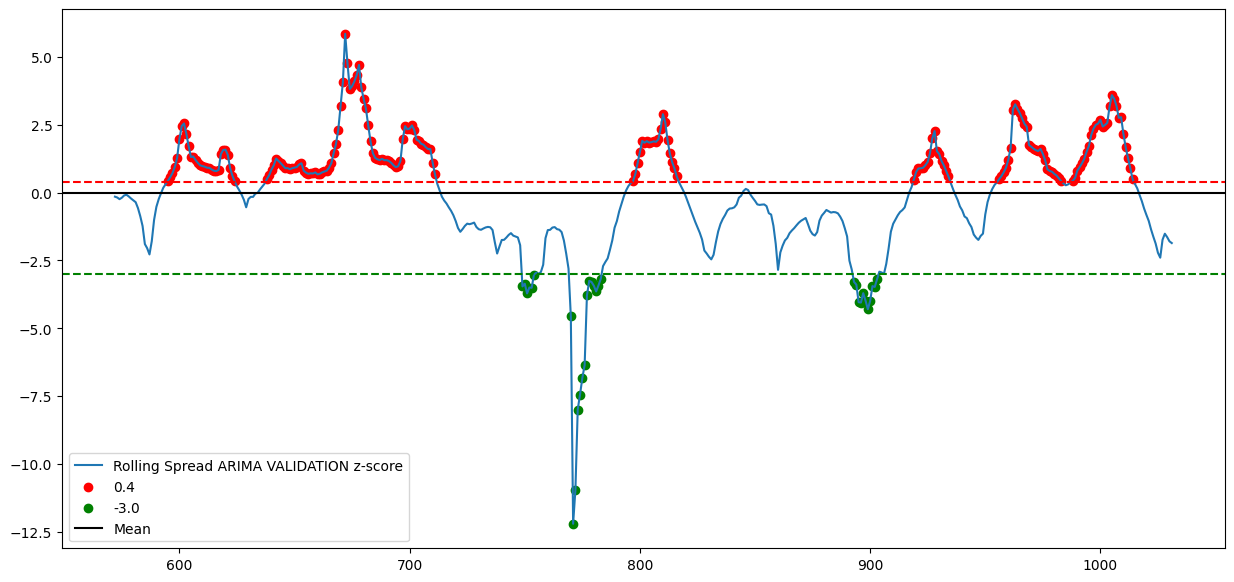

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 533.5258194215846, 1057.227501635025, 1572.1312608756703, 2088.595809633379, 2615.752146356669, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 3138.5241854906326, 2644.7166343983204, 2146.1823171280057, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.7285203163256, 1637.72852031

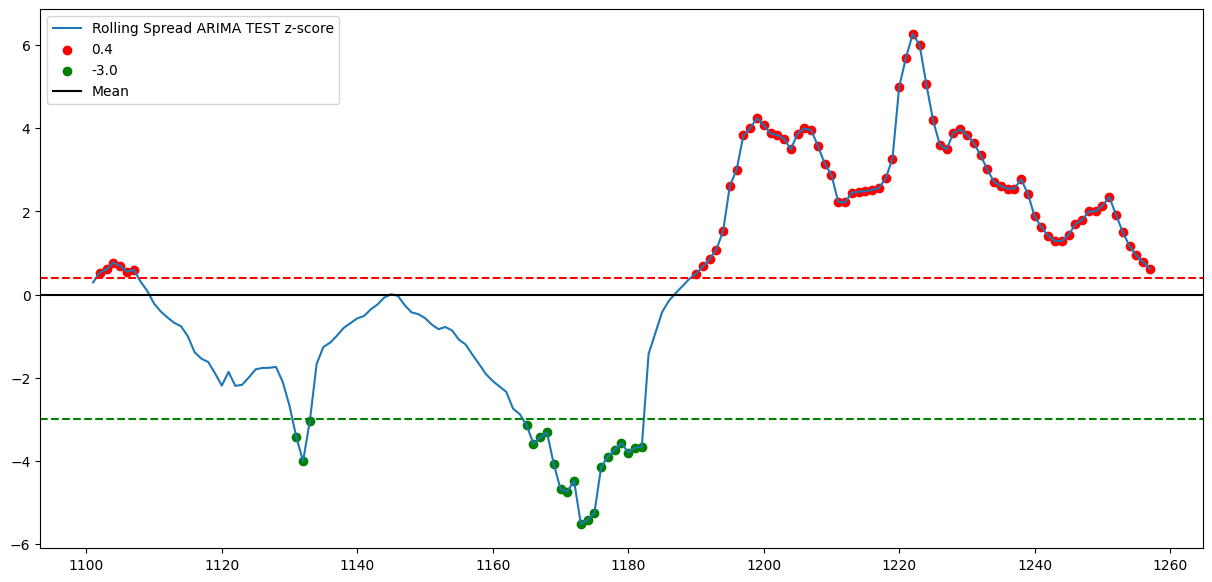

Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 70, 'window2': 13}
Money on validation data 82552.28090581088
Money on test data 39495.02337539573


In [220]:
money_val = trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_val)
buy_signal_plots(spread_ARIMA_val,S1_val,S2_val,window1,window2,sell_threshold,buy_threshold,label="ARIMA VALIDATION")

money_test = trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_test)
buy_signal_plots(spread_ARIMA_test,S1_test,S2_test,window1,window2,sell_threshold,buy_threshold,label="ARIMA TEST")


print("Optimal Parameters",byopt.optimize_results["best_params"])
print("Money on validation data",money_val[-1])
print("Money on test data",money_test[-1])

In [221]:
exponational_risk = ExponationalUtility(0.006)
byopt_exp =  gridsearchOpt(exponational_risk)
params_exp = byopt_exp.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_exp.optimize_results["best_params"])
window1_exp = byopt_exp.optimize_results["best_params"]["window1"]
window2_exp = byopt_exp.optimize_results["best_params"]["window2"]
sell_threshold_exp = byopt_exp.optimize_results["best_params"]["sell_threshold"]
buy_threshold_exp = byopt_exp.optimize_results["best_params"]["buy_threshold"]
clear_threshold_exp = byopt_exp.optimize_results["best_params"]["clear_threshold"]


Total Parameters : 4375
Current Progress: 1/4375 : best_score : -0.9940179640539349 
Current Progress: 101/4375 : best_score : -0.9940179640539349 
Current Progress: 201/4375 : best_score : -0.9940179640539349 
Current Progress: 301/4375 : best_score : -0.9940179640539349 
Current Progress: 401/4375 : best_score : -0.9940179640539349 
Current Progress: 501/4375 : best_score : -0.9940179640539349 
Current Progress: 601/4375 : best_score : -0.9940179640539349 
Current Progress: 701/4375 : best_score : -0.9940179640539349 
Current Progress: 801/4375 : best_score : -0.9940179640539349 
Current Progress: 901/4375 : best_score : -0.9926261643955788 
Current Progress: 1001/4375 : best_score : -0.1676468653590704 
Current Progress: 1101/4375 : best_score : -0.1676468653590704 
Current Progress: 1201/4375 : best_score : -0.1676468653590704 
Current Progress: 1301/4375 : best_score : -0.1676468653590704 
Current Progress: 1401/4375 : best_score : -0.1676468653590704 
Current Progress: 1501/4375 

In [222]:

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd


class RiskMeasure(ABC):

    @abstractmethod
    def calculate(self, money_arr):
        pass


In [223]:
class MeanSemiDeviation(RiskMeasure):

    def __init__(self,chi=0.3):
        self.chi = chi

    def calculate(self, money_arr):
        """
        Calcilate the mean semi deviation of a money array"
        rho = E[loss] + chi*E[[E[loss]-loss]_+]
        """
        # Calculate loss returns 
   
        money_arr_arr = np.array(money_arr)

        # Calculate returns
        returns = np.diff(money_arr_arr)
        # Fill NaN values with 0
        returns = np.nan_to_num(returns)

        # Calculate mean and semi-deviation
        mean_returns = np.mean(returns)
        semi_deviation = np.mean(np.maximum(mean_returns-returns, 0))

        return mean_returns - self.chi*semi_deviation


class TotalSemiDeviation(RiskMeasure):

    def __init__(self, chi=0.4):
        self.chi = chi

    # def calculate(self, money_arr):
    #     """
    #     Calculate the drawdown of a money array
    #     """
    #     # Convert to numpy array
    #     money_arr = np.array(money_arr)
        
    #    # Calculate drawdown
    #     money_diff = np.minimum(np.diff(money_arr)[1:],0)

    #     return money_arr[-1] + 8*np.sum(money_diff)
    
    def calculate(self, money_arr):
        """
        Calculate the drawdown of a money array
        """
        # Convert to numpy array
        money_arr = np.array(money_arr)

        # Calculate returns
        money_diff_rtn = np.diff(money_arr)

        # Fill NaN values with 0
        money_diff_rtn = np.nan_to_num(money_diff_rtn)
        
       # Calculate drawdown
        money_diff_rtn_dv = np.maximum(np.mean(money_diff_rtn)-money_diff_rtn,0)

        return np.sum(money_diff_rtn) - self.chi*np.sum(money_diff_rtn_dv)
    

class TotalDeviation(RiskMeasure):

    def __init__(self, chi=0.4):
        self.chi = chi

    
    def calculate(self, money_arr):
        """
        Calculate the drawdown of a money array
        """
        # Convert to numpy array
        money_arr = np.array(money_arr)

        # Calculate returns
        money_diff_rtn = np.diff(money_arr)

        # Fill NaN values with 0
        money_diff_rtn = np.nan_to_num(money_diff_rtn)
        
       # Calculate drawdown
        money_diff_rtn_dv = np.maximum(money_diff_rtn,0)

        return np.sum(money_diff_rtn) - self.chi*np.sum(money_diff_rtn_dv)
    

    

# class MeanSemiDeviation(RiskMeasure):

#     def __init__(self, chi=0.4):
#         self.chi = chi

#     def calculate(self, money_arr):
#         """
#         Calculate the mean semi deviation of a money array
#         """
#         # Convert to numpy array
#         money_arr = np.array(money_arr)

#         # Calculate returns
#         diff = np.diff(money_arr)
#         # Fill NaN values with 0
#         diff = np.nan_to_num(diff)

#         # Calculate 
#         mean_diff = np.mean(diff)
#         semi_deviation = np.mean(np.minimum(diff-mean_diff, 0))

#         return mean_diff + self.chi * semi_deviation

In [224]:
mean_semi_deviation = MeanSemiDeviation(chi=0.8)
byopt_msd =  gridsearchOpt(mean_semi_deviation)
params_msd = byopt_msd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_msd.optimize_results["best_params"])
window1_msd = byopt_msd.optimize_results["best_params"]["window1"]
window2_msd = byopt_msd.optimize_results["best_params"]["window2"]
sell_threshold_msd = byopt_msd.optimize_results["best_params"]["sell_threshold"]    
buy_threshold_msd = byopt_msd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_msd = byopt_msd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_msd.optimize_results["best_params"])

Total Parameters : 4375
Current Progress: 1/4375 : best_score : 0.0 
Current Progress: 101/4375 : best_score : 0.0 
Current Progress: 201/4375 : best_score : 0.0 
Current Progress: 301/4375 : best_score : 0.0 
Current Progress: 401/4375 : best_score : 0.0 
Current Progress: 501/4375 : best_score : 0.0 
Current Progress: 601/4375 : best_score : 0.0 
Current Progress: 701/4375 : best_score : 0.0 
Current Progress: 801/4375 : best_score : 0.0 
Current Progress: 901/4375 : best_score : 0.0 
Current Progress: 1001/4375 : best_score : 0.0 
Current Progress: 1101/4375 : best_score : 0.0 
Current Progress: 1201/4375 : best_score : 0.0 
Current Progress: 1301/4375 : best_score : 0.0 
Current Progress: 1401/4375 : best_score : 0.0 
Current Progress: 1501/4375 : best_score : 0.0 
Current Progress: 1601/4375 : best_score : 0.0 
Current Progress: 1701/4375 : best_score : 0.0 
Current Progress: 1801/4375 : best_score : 26.180046823174962 
Current Progress: 1901/4375 : best_score : 26.180046823174962

In [241]:
# Do the same thing for TotalSemiDeviation
total_semi_deviation = TotalSemiDeviation(chi=0.25)
print(total_semi_deviation.chi)
byopt_tsd =  gridsearchOpt(total_semi_deviation)
params_tsd = byopt_tsd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_tsd.optimize_results["best_params"])
window1_tsd = byopt_tsd.optimize_results["best_params"]["window1"]
window2_tsd = byopt_tsd.optimize_results["best_params"]["window2"]
sell_threshold_tsd = byopt_tsd.optimize_results["best_params"]["sell_threshold"]
buy_threshold_tsd = byopt_tsd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_tsd = byopt_tsd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_tsd.optimize_results["best_params"])

0.25
Total Parameters : 4375
Current Progress: 1/4375 : best_score : 0.0 
Current Progress: 101/4375 : best_score : 0.0 
Current Progress: 201/4375 : best_score : 0.0 
Current Progress: 301/4375 : best_score : 0.0 
Current Progress: 401/4375 : best_score : 0.0 
Current Progress: 501/4375 : best_score : 0.0 
Current Progress: 601/4375 : best_score : 0.0 
Current Progress: 701/4375 : best_score : 0.0 
Current Progress: 801/4375 : best_score : 0.0 
Current Progress: 901/4375 : best_score : 20856.424120815707 
Current Progress: 1001/4375 : best_score : 20856.424120815707 
Current Progress: 1101/4375 : best_score : 20856.424120815707 
Current Progress: 1201/4375 : best_score : 20856.424120815707 
Current Progress: 1301/4375 : best_score : 20856.424120815707 
Current Progress: 1401/4375 : best_score : 20856.424120815707 
Current Progress: 1501/4375 : best_score : 20856.424120815707 
Current Progress: 1601/4375 : best_score : 20856.424120815707 
Current Progress: 1701/4375 : best_score : 2085

In [226]:
# Do it with TotalDeviation
total_deviation = TotalDeviation(chi=0.8)
byopt_td =  gridsearchOpt(total_deviation)
params_td = byopt_td.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid)
print(byopt_td.optimize_results["best_params"])
window1_td = byopt_td.optimize_results["best_params"]["window1"]
window2_td = byopt_td.optimize_results["best_params"]["window2"]
sell_threshold_td = byopt_td.optimize_results["best_params"]["sell_threshold"]
buy_threshold_td = byopt_td.optimize_results["best_params"]["buy_threshold"]
clear_threshold_td = byopt_td.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_td.optimize_results["best_params"])


Total Parameters : 4375
Current Progress: 1/4375 : best_score : 0.0 
Current Progress: 101/4375 : best_score : 0.0 
Current Progress: 201/4375 : best_score : 0.0 
Current Progress: 301/4375 : best_score : 0.0 
Current Progress: 401/4375 : best_score : 0.0 
Current Progress: 501/4375 : best_score : 0.0 
Current Progress: 601/4375 : best_score : 0.0 
Current Progress: 701/4375 : best_score : 0.0 
Current Progress: 801/4375 : best_score : 0.0 
Current Progress: 901/4375 : best_score : 0.0 
Current Progress: 1001/4375 : best_score : 0.0 
Current Progress: 1101/4375 : best_score : 0.0 
Current Progress: 1201/4375 : best_score : 0.0 
Current Progress: 1301/4375 : best_score : 0.0 
Current Progress: 1401/4375 : best_score : 0.0 
Current Progress: 1501/4375 : best_score : 0.0 
Current Progress: 1601/4375 : best_score : 0.0 
Current Progress: 1701/4375 : best_score : 0.0 
Current Progress: 1801/4375 : best_score : 0.0 
Current Progress: 1901/4375 : best_score : 0.0 
Current Progress: 2001/4375 

In [ ]:
{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.6736842105263159, 'window1': 23, 'window2': 12}

In [227]:
rd_window_1 = 65
rd_window_2 = 10
rd_sell_threshold = 1
rd_buy_threshold = -2
rd_clear_threshold = 0

# Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 65, 'window2': 12}
# Money on validation data 75911.82971778436
# Money on test data 38066.41664118262

In [242]:
money_val_rd = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_val_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_val_exp_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)
money_val_msd_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)
money_val_tsd_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_tsd, window2_tsd,sell_threshold_tsd,buy_threshold_tsd,clear_threshold_tsd)
money_val_td_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_td, window2_td,sell_threshold_td,buy_threshold_td,clear_threshold_td)

In [229]:


money_arr = np.array(money_val_exp_opt)

# Calculate returns
money_diff_rtn = np.diff(money_arr)/ money_arr[:-1]

# Fill NaN values with 0
money_diff_rtn = np.nan_to_num(money_diff_rtn)

# Calculate drawdown
money_diff_rtn_dv = np.minimum(money_diff_rtn,0)

print(np.sum(money_diff_rtn) + 0.000*np.sum(money_diff_rtn_dv))


398.4494909683493


In [230]:
pd.Series(money_diff_rtn).to_csv("money_diff_rtn_xp.csv")

In [231]:
np.sum(np.minimum(np.diff(money_val_exp_opt),0))

-42104.01073498059

In [232]:
# Calculate Exponational Utility

def utility(risk_aversion,money_arr):
    return -1*np.mean(np.exp(-risk_aversion *np.array(money_arr)))

print("Risk Aversion Utility rd",utility(0.009,money_val_rd))
print("Risk Aversion Utility opt",utility(0.009,money_val_opt))
print("Risk Aversion Utility exp",utility(0.009,money_val_exp_opt))
print("Risk Aversion Utility msd",utility(0.009,money_val_msd_opt))


Risk Aversion Utility rd -16463640.94400226
Risk Aversion Utility opt -0.17270497828627324
Risk Aversion Utility exp -0.07326585932717206
Risk Aversion Utility msd -0.09014591175162122


In [233]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.2142082488099,
 971.4702793156173,
 1457.5431114743621,
 1944.0979094710349,
 2441.4350206927966,
 2934.520921193781,
 3426.2913682095696,
 3908.349886639085,
 4396.765805969503,
 4894.377461957076,
 5400.247189109047,
 5901.980962793682,
 6404.382010950167,
 6901.958730401068,
 7408.142522117675,
 7917.922178572962,
 8424.882779433452,
 8930.381467631085,
 9433.691511715688,
 9938.385935991168,
 10440.659116302653,
 10937.191516930927,
 11430.816334428164,
 11921.109184799496,
 12411.868082743978,
 12907.141498837203,
 13407.038354249087,
 13908.523343871602,
 14400.292354404526,
 14882.151448716742,
 14882.15144871674

In [234]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.2142082488099,
 971.4702793156173,
 1457.5431114743621,
 1944.0979094710349,
 2441.4350206927966,
 2934.520921193781,
 3426.2913682095696,
 3908.349886639085,
 4396.765805969503,
 4894.377461957076,
 5400.247189109047,
 5901.980962793682,
 6404.382010950167,
 6901.958730401068,
 7408.142522117675,
 7917.922178572962,
 8424.882779433452,
 8930.381467631085,
 9433.691511715688,
 9938.385935991168,
 10440.659116302653,
 10937.191516930927,
 11430.816334428164,
 11921.109184799496,
 12411.868082743978,
 12907.141498837203,
 13407.038354249087,
 13908.523343871602,
 14400.292354404526,
 14882.151448716742,
 14882.15144871674

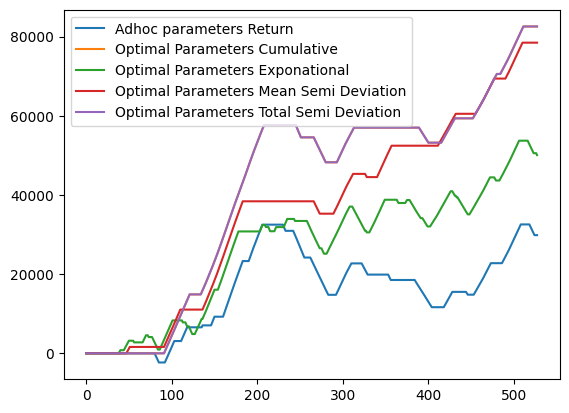

In [243]:
plt.plot(money_val_rd)
plt.plot(money_val_opt)
plt.plot(money_val_exp_opt)
plt.plot(money_val_msd_opt)
plt.plot(money_val_tsd_opt)
# plt.plot(money_val_td_opt)
plt.legend(["Adhoc parameters Return","Optimal Parameters Cumulative","Optimal Parameters Exponational","Optimal Parameters Mean Semi Deviation","Optimal Parameters Total Semi Deviation","Optimal Parameters Total Deviation"], loc="upper left")

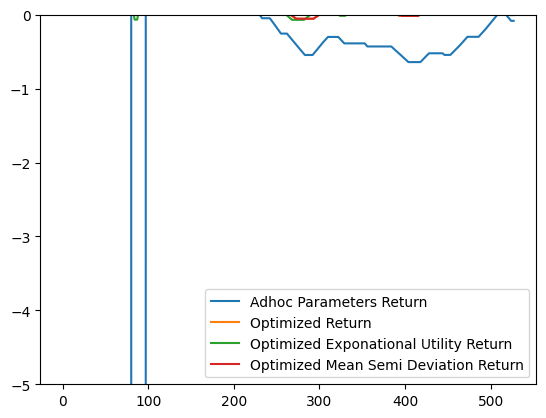

In [174]:
plt.plot(calculate_drawdown(money_val_rd),label="Adhoc Parameters Return")
plt.plot(calculate_drawdown(money_val_opt),label="Optimized Return")
plt.plot(calculate_drawdown(money_val_exp_opt),label="Optimized Exponational Utility Return")
plt.plot(calculate_drawdown(money_val_msd_opt),label="Optimized Mean Semi Deviation Return")
plt.ylim([-5,0])
plt.legend()


In [175]:
val_drawdown = np.min(calculate_drawdown(money_val_rd))
val_opt_drawdown = np.min(calculate_drawdown(money_val_opt))
val_exp_drawdown = np.min(calculate_drawdown(money_val_exp_opt))

print("Val drawdown",val_drawdown)
print("Val optimized drawdown",val_opt_drawdown)
print("Val optimized exponational drawdown",val_exp_drawdown)
print("Val optimized mean semi deviation drawdown",np.min(calculate_drawdown(money_val_msd_opt)))
print("Val optimized total semi deviation drawdown",np.min(calculate_drawdown(money_val_tsd_opt)))


Val drawdown -2312.0
Val optimized drawdown -0.054688866347196476
Val optimized exponational drawdown -0.06980768814761935
Val optimized mean semi deviation drawdown -0.054688866347196476
Val optimized total semi deviation drawdown -0.054688866347196476


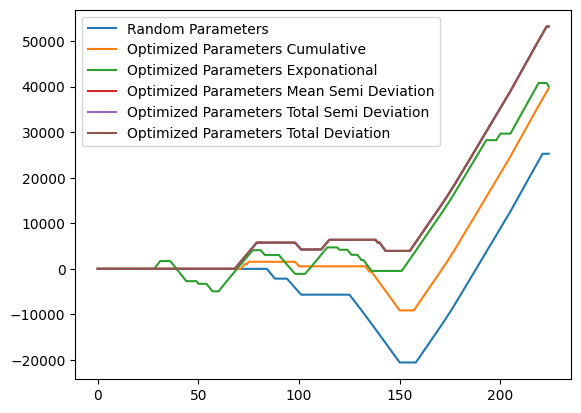

In [123]:
money_test_rd = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_test_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_test_exp_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)
money_test_msd_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)
money_test_tsd_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_tsd, window2_tsd,sell_threshold_tsd,buy_threshold_tsd,clear_threshold_tsd)
money_test_td_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_td, window2_td,sell_threshold_td,buy_threshold_td,clear_threshold_td)

plt.plot(money_test_rd)
plt.plot(money_test_opt)
plt.plot(money_test_exp_opt)
plt.plot(money_test_msd_opt)
plt.plot(money_test_tsd_opt)
plt.plot(money_test_td_opt)
plt.legend(["Random Parameters","Optimized Parameters Cumulative","Optimized Parameters Exponational","Optimized Parameters Mean Semi Deviation","Optimized Parameters Total Semi Deviation","Optimized Parameters Total Deviation"])

In [ ]:
print("Money gain using random parameters",money_test_rd[-1])
print("Money gain using optimized parameters",money_test_opt[-1])
print("Money gain using optimized parameters exponational",money_test_exp_opt[-1])

print("Performance gain over benchmark Cumilative  ",(money_test_opt[-1]- money_test_rd[-1])/money_test_rd[-1])

print("Performance gain over benchmark exponational",(money_test_exp_opt[-1]- money_test_rd[-1])/money_test_rd[-1])


In [ ]:
plt.plot(calculate_drawdown(money_test_rd),label="Adhoc Parameters")
plt.plot(calculate_drawdown(money_test_opt),label="Optimized Parameters Cumulative")
plt.plot(calculate_drawdown(money_test_exp_opt),label="Optimized Parameters Exponational")
plt.plot(calculate_drawdown(money_test_msd_opt),label="Optimized Parameters Mean Semi Deviation")
# plt.ylim(-1,0)
plt.legend()

In [ ]:
val_test_rd = calculate_drawdown(money_test_rd)
val_test_opt = calculate_drawdown(money_test_opt)
val_test_exp_op = calculate_drawdown(money_test_exp_opt)
val_test_msd_op = calculate_drawdown(money_test_msd_opt)

print("Test drawdown",np.min(val_test_rd))
print("Test optimized drawdown",np.min(val_test_opt))
print("Test optimized drawdown",np.min(val_test_exp_op))
print("Test optimized mean semi deviation drawdown",np.min(val_test_msd_op))

#Reduction in drawdown
print("Reduction in drawdown Cumilative  ",(np.min(val_test_rd)-np.min(val_test_opt))/np.min(val_test_rd))
print("Reduction in drawdown Exponational  ",(np.min(val_test_rd)-np.min(val_test_exp_op))/np.min(val_test_rd))
print("Reduction in drawdown Mean Semi Deviation  ",(np.min(val_test_rd)-np.min(val_test_msd_op))/np.min(val_test_rd))





In [ ]:
# Calculate sharpe from wealth
def sharpe_ratio(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    return (np.mean(daily_returns) / np.std(daily_returns))*np.sqrt(252)

# Calculate sharpe ratio on test data
sharpe_rd = sharpe_ratio(money_test_rd)
sharpe_opt = sharpe_ratio(money_test_opt)
sharpe_exp = sharpe_ratio(money_test_exp_opt)
sharpe_msd = sharpe_ratio(money_test_msd_opt)

print("Sharpe Ratio Random Parameters",sharpe_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_exp)
print("Sharpe Ratio Optimized Parameters Mean Semi Deviation",sharpe_msd)

In [ ]:
len(money_val_rd)

In [ ]:
# Calculate average drawdowns
def average_drawdown(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    drawdowns = (np.maximum.accumulate(daily_returns) - daily_returns)
    return np.mean(drawdowns)

In [ ]:
# calculate returns from portfolio wealth using numpy 
np.diff(money_val_rd)/money_val_rd[:-1]

In [ ]:
# Calculate sharpe on validation data
sharpe_val_rd = sharpe_ratio(money_val_rd)
sharpe_val_opt = sharpe_ratio(money_val_opt)
sharpe_val_exp = sharpe_ratio(money_val_exp_opt)
print("Sharpe Ratio Random Parameters",sharpe_val_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_val_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_val_exp)

In [ ]:
returns = pd.Series(money_test_exp_opt).pct_change()[1:]
portfolio_returns = pd.Series(money_test_exp_opt).sum(axis=1)
# cumulative_returns = (1 + portfolio_returns).cumprod() * 
cumilative_returns = money_test_exp_opt

# roi = (cumulative_returns[-1] / self.portfolio_value - 1) * 100
sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
drawdown = (cumilative_returns.cummax() - cumilative_returns) / cumilative_returns.cummax()
max_drawdown = drawdown.max() * 100

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
result = adfuller(pm.data['Spread_Close'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

In [ ]:
plot_acf(pm.data['Spread_Close'],lags=50)
plt.show()

In [ ]:
plot_pacf(pm.data['Spread_Close'],lags=50)
plt.show()

In [ ]:
result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

In [ ]:
plot_acf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [ ]:
plot_pacf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [ ]:

result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])